# Preparation

In [2]:
!pip install pandas
!pip install matplotlib

# Import libraries
import pandas as pd

from Utils import *
%matplotlib inline

### Global Parameters

In [45]:
# Specify the data path
datafile = '//mnt/beegfs/home/psamfass/ML/hipCollections/build/benchmarks/all_cg.csv'

output_keys = ['Key','Benchmark', 'Label', 'Distribution', 'MatchingRate', 'Multiplicity', \
                'Occupancy', 'GPU Time (sec)', 'Elem/s (elem/sec)', 'ProbingCGSize']

### Import Data

In [46]:
# Read csv file
rawdf = pd.read_csv(datafile)

# Filter out skipped tests
perfdf = rawdf[rawdf["Key"] == rawdf["Value"]].reset_index(drop=True)


# Add labels
perfdf['Label'] = perfdf["Key"]
perfdf.loc[perfdf['Distribution'].notnull(), 'Label'] += "_" + perfdf['Distribution']
perfdf['Label'] += '_CG'+perfdf["ProbingCGSize"].astype(str)

# Trim data frame for visualization
perfdf = perfdf[output_keys]

# Visualization

### Visualization Parameters

In [38]:
# Get benchmark list
unique_bms = perfdf["Benchmark"].unique()
for it in unique_bms:
    print(it)

static_multimap_insert_uniform_multiplicity
static_multimap_insert_unique_occupancy
static_multimap_insert_gaussian_skew
static_multimap_retrieve_uniform_occupancy
static_multimap_retrieve_uniform_matching_rate
static_multimap_retrieve_uniform_multiplicity
static_multimap_query_uniform_occupancy
static_multimap_query_uniform_matching_rate
static_multimap_query_uniform_multiplicity
static_multimap_count_uniform_occupancy
static_multimap_count_uniform_matching_rate
static_multimap_count_uniform_multiplicity


### `insert` performance by varying key multiplicities
<ul>
<li>100'000'000 insertions</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.8</li>
<li>UNIFORM distribution</li>
</ul>

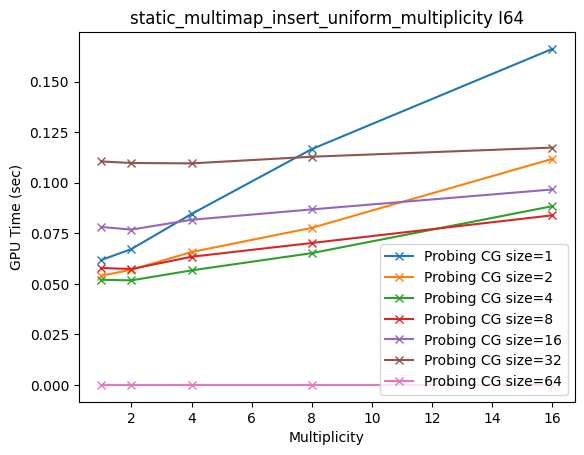

In [62]:
for bm in unique_bms:
    flag = "static_multimap_insert_uniform_multiplicity" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Multiplicity"], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title("static_multimap_insert_uniform_multiplicity I64")
          plt.xlabel("Multiplicity")
          plt.ylabel("GPU Time (sec)")
          plt.legend()


### `insert` performance by varying occupancies
<ul>
<li>100'000'000 insertions</li>
<li>Fixed matching rate: 0.5</li>
</ul>

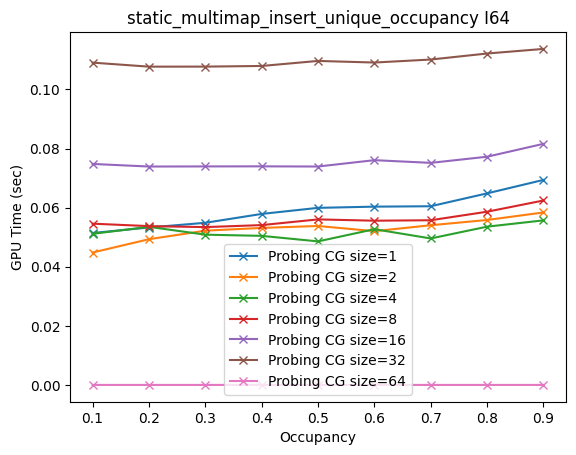

In [67]:
for bm in unique_bms:
    flag = "static_multimap_insert_unique_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()


### `count` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

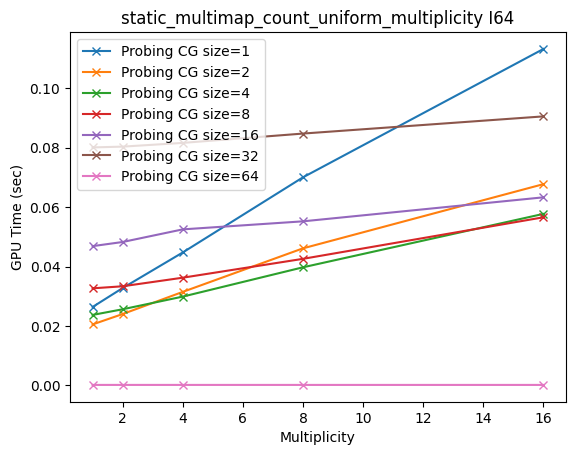

In [68]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `count` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

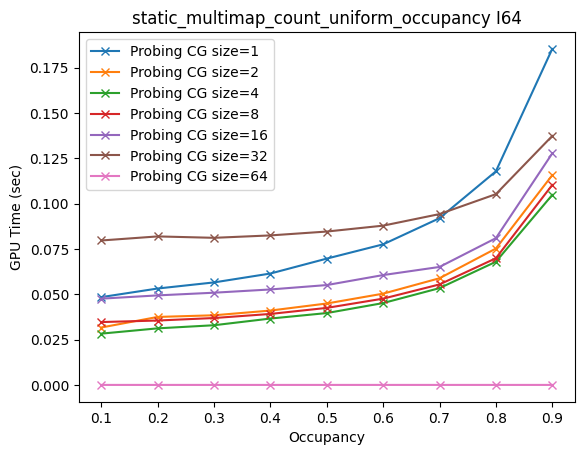

In [69]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `count` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed occupancy: 0.5</li>
</ul>

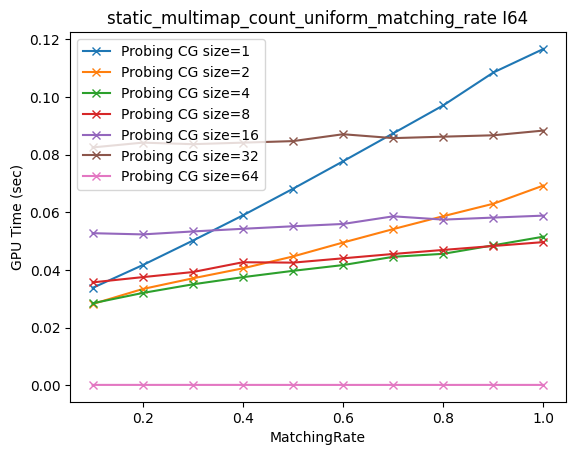

In [71]:
for bm in unique_bms:
    flag = "static_multimap_count_uniform_matching_rate" == bm
    x_param = "MatchingRate"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

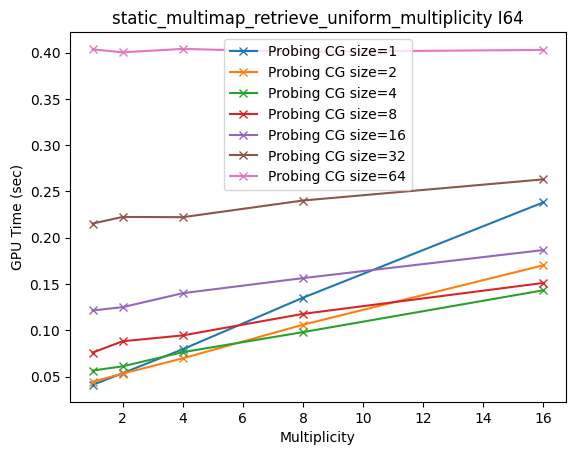

In [72]:
for bm in unique_bms:
    flag = "static_multimap_retrieve_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

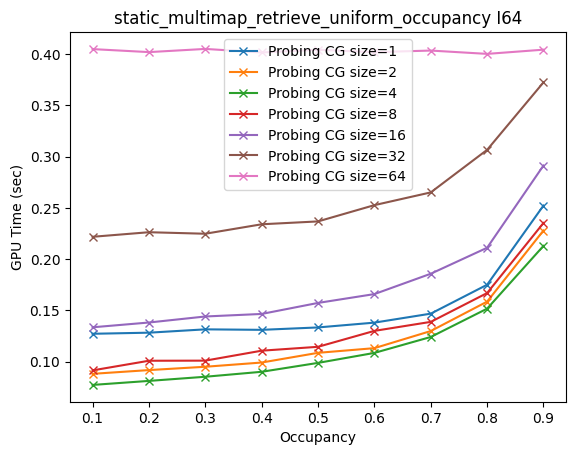

In [73]:
for bm in unique_bms:
    flag = "static_multimap_retrieve_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `retrieve` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed occupancy: 0.5</li>
</ul>

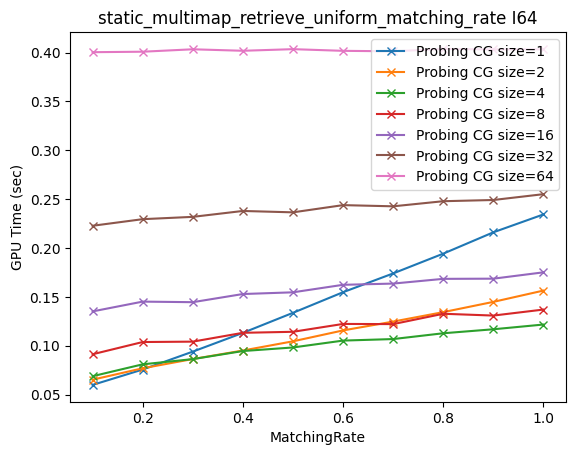

In [76]:
static_multimap_query_uniform_multiplicity

### `query` (`retrieve`  + `count`) performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
<li>UNIFORM distribution</li>
</ul>

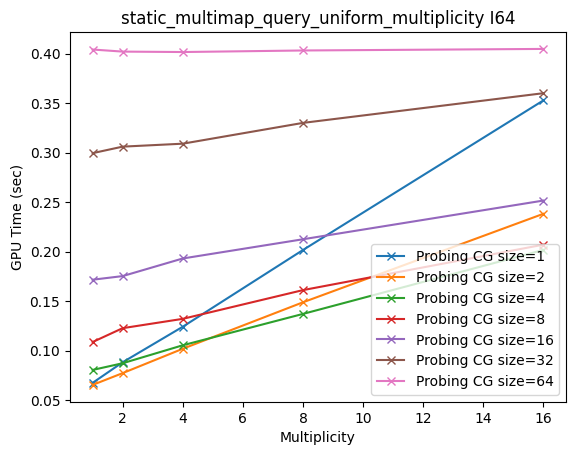

In [77]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_multiplicity" == bm
    x_param = "Multiplicity"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `query` (`retrieve`  + `count`) performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

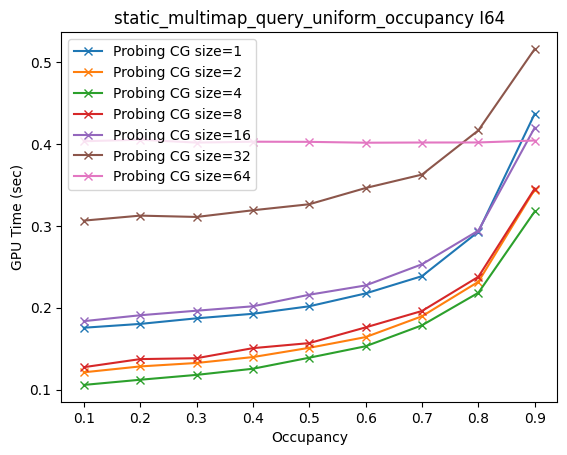

In [78]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_occupancy" == bm
    x_param = "Occupancy"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `query` (`retrieve`  + `count`) performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>100'000'000 probing keys</li>
<li>Fixed matching rate: 0.5</li>
</ul>

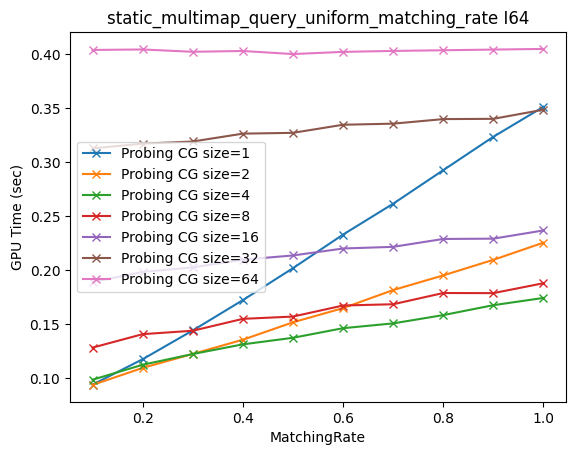

In [79]:
for bm in unique_bms:
    flag = "static_multimap_query_uniform_matching_rate" == bm
    x_param = "MatchingRate"
    key_type = "I64"
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]==key_type)]

        groups = tmpdf.groupby("ProbingCGSize")

        for group_name, group_data in groups:
          plt.plot(group_data[x_param], group_data["GPU Time (sec)"], label="Probing CG size="+str(group_name), marker="x")

          plt.title(bm+ " "+ key_type)
          plt.xlabel(x_param)
          plt.ylabel("GPU Time (sec)")
          plt.legend()